# Avaliação qualidade da explicação do XAI

Neste notebook, avaliaremos a qualidade e a confiabilidade das explicações geradas pelos métodos de XAI aplicados ao modelo CNN-LSTM. Enquanto o notebook anterior identificou quais sensores e ciclos temporais são mais relevantes para as previsões de RUL, este estudo verifica se essas explicações realmente representam o comportamento do modelo. Serão realizadas as seguintes avaliações:

1. **Fidelity**: Se remover as variáveis importantes o erro aumenta?
2. **Infidelity**: A explicação realmente representa o modelo?
3. **Stability**: Mudanças pequenas nos dados, explicação muda pouco?
4. **Sparsity**: Quantas variáveis são necessárias para explicar?
5. **Completeness**: A explicação cobre toda a decisão?

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sys.path.append(os.path.abspath('../..')) 

from src.xai.xai_baseExplainer import BaseExplainer
from src.xai.xai_shapExplainer import ShapExplainer
from src.xai.xai_limeExplainer import LimeExplainer
from src.xai.xai_igExplainer import IntegratedGradientsExplainer
from src.xai.xai_timeshapExplainer import TimeShapExplainer
from src.xai.xai_windowshapExplainer import WindowShapExplainer
from src.xai.xaI_gradcamExplainer import GradCamExplainer
from src.xai.xai_saliencymapsExplainer import SaliencyMapsExplainer

In [2]:
DATASET_01 = "FD001"
model_path_001 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_01}.keras"
x_path_001 = f"../../data/processed_data/X_test_{DATASET_01}.npz"
y_path_001 = f"../../data/processed_data/y_test_{DATASET_01}.npz"

DATASET_02 = "FD002"
model_path_002 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_02}.keras"
x_path_002 = f"../../data/processed_data/X_test_{DATASET_02}.npz"
y_path_002 = f"../../data/processed_data/y_test_{DATASET_02}.npz"

DATASET_03 = "FD003"
model_path_003 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_03}.keras"
x_path_003 = f"../../data/processed_data/X_test_{DATASET_03}.npz"
y_path_003 = f"../../data/processed_data/y_test_{DATASET_03}.npz"

DATASET_04 = "FD004"
model_path_004 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_04}.keras"
x_path_004 = f"../../data/processed_data/X_test_{DATASET_04}.npz"
y_path_004 = f"../../data/processed_data/y_test_{DATASET_04}.npz"

## 1. Fidelity: a remoção dos sensores mais importantes piora a previsão?

A ideia seria gerar um ranking global de sensores, utilizando 1000 amostras e aplicando o SHAP neles, atribuindo uma pontuação a cada sensor. Após isso, foram feitos 3 testes diferentes para a comparação com o erro que temos no momento, trocando *k* sensores por valores de referência calculados no conjunto de treinamento (mediana) e medimos o impacto no erro. Os testes foram:

 - Substituindo os *k* sensores mais relevantes
 - Substituindo *k* sensores menos relevantes 
 - Substituindo *k* sensores aleatórios

Para uma explicação ser considerada mais fiel, quando removemos os sensores mais importantes, o ideal é o aumento das métricas de erro.

Referências:

https://arxiv.org/abs/1806.07421

https://explainableaiworkbook.com/02-explainable-machine-learning/09-evaluating-explanations/01-fidelity

In [1]:
def obter_atribuicao_2d(explainer, indice):
    """Retorna atribuicoes no formato (tempo, sensores), com os valores das atribuicoes."""
    atribuicao = np.asarray(explainer.explain_instance(indice))
    if atribuicao.ndim == 4: 
        atribuicao = atribuicao[0, :, :, 0]
    elif atribuicao.ndim == 3:
        atribuicao = atribuicao[0]
    return atribuicao

def calcular_metricas(y_real, y_pred):
    """Calcula MAE e RMSE entre y_real e y_pred."""
    erro = y_real.reshape(-1) - y_pred.reshape(-1)
    return np.mean(np.abs(erro)), np.sqrt(np.mean(erro**2))

def ranking_sensores(explainer, num_amostras_explicacao=1000):
    """Calcula um ranking unico pela media de atribuicoes."""
    n = min(num_amostras_explicacao, len(explainer.X_test))
    importancia_global = np.zeros(explainer.X_test.shape[2])
    for indice in range(n):
        atribuicao = obter_atribuicao_2d(explainer, indice)
        importancia_global += np.sum(np.abs(atribuicao), axis=0)
    importancia_global /= n
    return np.argsort(importancia_global)[::-1], importancia_global

def mascarar_sensores(X, sensores, referencia):
    """Mascarar sensores em X com valores de referencia, para avaliacao de fidelity."""
    X_mascarado = X.copy()
    for sensor in sensores:
        X_mascarado[:, :, sensor] = referencia[sensor]
    return X_mascarado

def avaliar_fidelity(explainer, X, y, referencia, k_values=(1, 3, 5), num_amostras_explicacao=1000, seed=42):
    ranking, importancia_global = ranking_sensores(explainer, num_amostras_explicacao)
    mae_original, rmse_original = calcular_metricas(y, explainer.model.predict(X, verbose=0))
    rng, resultados = np.random.default_rng(seed), []
    for k in k_values:
        grupos = {
            "Top-k XAI": ranking[:k],
            "Bottom-k XAI": ranking[-k:],
            "Aleatorio": rng.choice(X.shape[2], size=k, replace=False),
        }
        for estrategia, sensores in grupos.items():
            predicao = explainer.model.predict(mascarar_sensores(X, sensores, referencia), verbose=0)
            mae, rmse = calcular_metricas(y, predicao)
            resultados.append({
                "Estrategia": estrategia, "k sensores removidos": k,
                "Sensores removidos": ", ".join(map(str, explainer.feature_names[sensores])),
                "MAE": mae, "RMSE": rmse,
                "Delta MAE vs. original": mae - mae_original,
                "Delta RMSE vs. original": rmse - rmse_original,
            })
    ranking_df = pd.DataFrame({
        "Sensor": explainer.feature_names[ranking],
        "Importancia media (atribuicao)": importancia_global[ranking],
    })
    return pd.DataFrame(resultados), {"MAE": mae_original, "RMSE": rmse_original}, ranking_df

def plotar_fidelity(resultados, dataset, metodo):
    fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
    for estrategia, grupo in resultados.groupby("Estrategia"):
        eixos[0].plot(grupo["k sensores removidos"], grupo["Delta MAE vs. original"], marker="o", label=estrategia)
        eixos[1].plot(grupo["k sensores removidos"], grupo["Delta RMSE vs. original"], marker="o", label=estrategia)
    for eixo, metrica in zip(eixos, ["MAE", "RMSE"]):
        eixo.axhline(0, color="black", linewidth=0.8)
        eixo.set(xlabel="Numero de sensores removidos (k)", ylabel=f"Delta {metrica} vs. original")
        eixo.grid(alpha=0.3); eixo.legend()
    fig.suptitle(f"Fidelity por remocao - {metodo} - {dataset}")
    plt.tight_layout(); plt.show()


Métricas sem remoção: {'MAE': np.float64(10.09663715143679), 'RMSE': np.float64(14.15571717378156)}


,Sensor,Importancia media (atribuicao)
0,s_11,17.485
1,s_12,14.507
2,s_7,11.687
3,s_15,11.591
4,s_4,10.976
5,s_2,8.450
6,s_20,7.801
7,s_3,6.278
8,s_8,6.134
9,s_21,5.976


,Estrategia,k sensores removidos,Sensores removidos,MAE,RMSE,Delta MAE vs. original,Delta RMSE vs. original
0,Top-k XAI,1,s_11,11.119,15.187,1.022,1.031
1,Bottom-k XAI,1,s_5,10.097,14.156,0.000,0.000
2,Aleatorio,1,setting_2,10.003,14.090,-0.094,-0.066
3,Top-k XAI,3,"s_11, s_12, s_7",13.753,19.922,3.656,5.767
4,Bottom-k XAI,3,"s_6, s_16, s_5",10.097,14.157,0.000,0.001
5,Aleatorio,3,"s_14, s_8, s_12",11.397,15.723,1.301,1.567
6,Top-k XAI,5,"s_11, s_12, s_7, s_15, s_4",15.996,24.869,5.899,10.714
7,Bottom-k XAI,5,"s_14, setting_1, s_6, s_16, s_5",10.323,14.327,0.226,0.171
8,Aleatorio,5,"setting_2, s_12, s_20, s_3, s_11",13.779,19.883,3.682,5.727


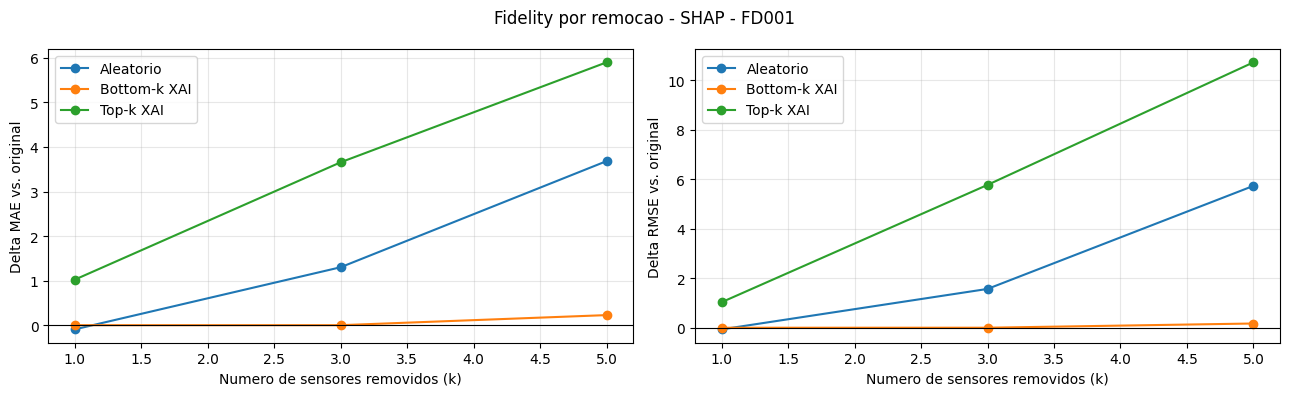

In [4]:
X_train_fd001 = np.load("../../data/processed_data/X_train_FD001.npz")["dados"]
referencia_fd001 = np.median(X_train_fd001, axis=(0, 1))

shap_fd001 = ShapExplainer(model_path_001, x_path_001, y_path_001, background_size=100)
resultados_fidelity_shap_fd001, metricas_originais_fd001, ranking_shap_fd001 = avaliar_fidelity(
    explainer=shap_fd001, X=shap_fd001.X_test, y=shap_fd001.y_test,
    referencia=referencia_fd001, k_values=(1, 3, 5), num_amostras_explicacao=1000
)

print("Métricas sem remoção:", metricas_originais_fd001)
display(ranking_shap_fd001.head(10).round(3))
display(resultados_fidelity_shap_fd001.round(3))
plotar_fidelity(resultados_fidelity_shap_fd001, dataset="FD001", metodo="SHAP")

### FD001

A remocao dos sensores mais importantes aumenta o erro de forma progressiva, com um comportamento semelhante do MAE e RMSE. Os sensores menos importantes praticamente nao alteram o desempenho, reforcando a fidelity do ranking SHAP. O controle aleatorio tambem piora o modelo, principalmente em `k=5` porque incluiu `s_11` e `s_12`(que são sensores considerados importantes). Já retirando os sensores de maior importância gerou os piores resultados, demonstrando a fidelidade.

Métricas sem remoção: {'MAE': np.float64(12.254957572835856), 'RMSE': np.float64(16.319196584738147)}


,Sensor,Importancia media (atribuicao)
0,s_11,22.679
1,s_15,15.560
2,s_4,12.183
3,s_7,8.740
4,s_2,8.475
5,s_17,8.032
6,s_12,7.822
7,s_6,7.184
8,s_21,6.092
9,s_3,5.662


,Estrategia,k sensores removidos,Sensores removidos,MAE,RMSE,Delta MAE vs. original,Delta RMSE vs. original
0,Top-k XAI,1,s_11,12.976,16.834,0.721,0.515
1,Bottom-k XAI,1,s_1,12.255,16.319,0.000,0.000
2,Aleatorio,1,setting_3,12.255,16.319,0.000,0.000
3,Top-k XAI,3,"s_11, s_15, s_4",16.073,21.640,3.818,5.321
4,Bottom-k XAI,3,"s_5, setting_3, s_1",12.255,16.319,0.000,0.000
5,Aleatorio,3,"s_15, s_8, s_13",12.937,16.665,0.682,0.346
6,Top-k XAI,5,"s_11, s_15, s_4, s_7, s_2",17.653,24.381,5.398,8.062
7,Bottom-k XAI,5,"s_18, s_19, s_5, setting_3, s_1",12.255,16.319,0.000,0.000
8,Aleatorio,5,"setting_2, s_12, setting_3, s_2, s_10",12.828,16.580,0.573,0.260


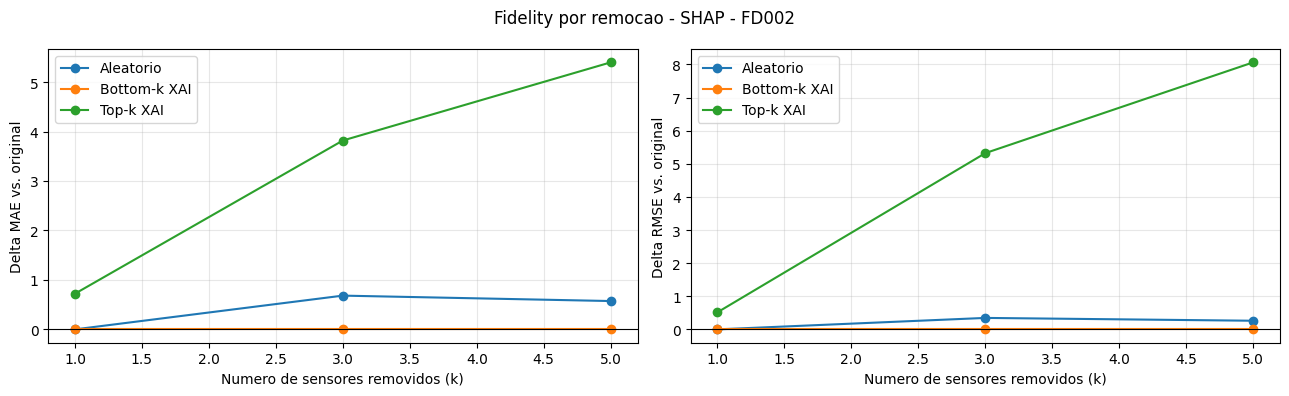

In [5]:
X_train_fd002 = np.load("../../data/processed_data/X_train_FD002.npz")["dados"]
referencia_fd002 = np.median(X_train_fd002, axis=(0, 1))

shap_fd002 = ShapExplainer(model_path_002, x_path_002, y_path_002, background_size=100)
resultados_fidelity_shap_fd002, metricas_originais_fd002, ranking_shap_fd002 = avaliar_fidelity(
    explainer=shap_fd002, X=shap_fd002.X_test, y=shap_fd002.y_test,
    referencia=referencia_fd002, k_values=(1, 3, 5), num_amostras_explicacao=1000
)

print("Métricas sem remoção:", metricas_originais_fd002)
display(ranking_shap_fd002.head(10).round(3))
display(resultados_fidelity_shap_fd002.round(3))
plotar_fidelity(resultados_fidelity_shap_fd002, dataset="FD002", metodo="SHAP")

### FD002

Resultado semelhante ao anterior, com gráficos parecidos. Novamente a fidelidade é comprovada, com a retirada dos sensores mais importantes, as métricas de erro do modelo aumentam bastante, enquanto a retirada dos menos importantes não causa impacto significante no MAE e RMSE.

Métricas sem remoção: {'MAE': np.float64(7.109504470619086), 'RMSE': np.float64(11.139080847668877)}


,Sensor,Importancia media (atribuicao)
0,s_12,37.435
1,s_6,31.857
2,s_7,25.611
3,s_11,17.674
4,s_4,13.163
5,s_13,12.212
6,s_8,10.896
7,s_15,8.549
8,s_21,7.633
9,s_20,6.416


,Estrategia,k sensores removidos,Sensores removidos,MAE,RMSE,Delta MAE vs. original,Delta RMSE vs. original
0,Top-k XAI,1,s_12,9.320,15.207,2.211,4.068
1,Bottom-k XAI,1,s_5,7.110,11.139,0.000,0.000
2,Aleatorio,1,setting_2,7.046,11.043,-0.064,-0.096
3,Top-k XAI,3,"s_12, s_6, s_7",9.612,16.411,2.503,5.272
4,Bottom-k XAI,3,"s_10, s_16, s_5",7.105,11.127,-0.005,-0.012
5,Aleatorio,3,"s_13, s_8, s_12",9.974,16.888,2.865,5.748
6,Top-k XAI,5,"s_12, s_6, s_7, s_11, s_4",11.497,19.103,4.387,7.964
7,Bottom-k XAI,5,"s_14, setting_2, s_10, s_16, s_5",7.081,11.065,-0.029,-0.074
8,Aleatorio,5,"setting_2, s_11, s_20, s_3, s_10",8.168,12.930,1.058,1.790


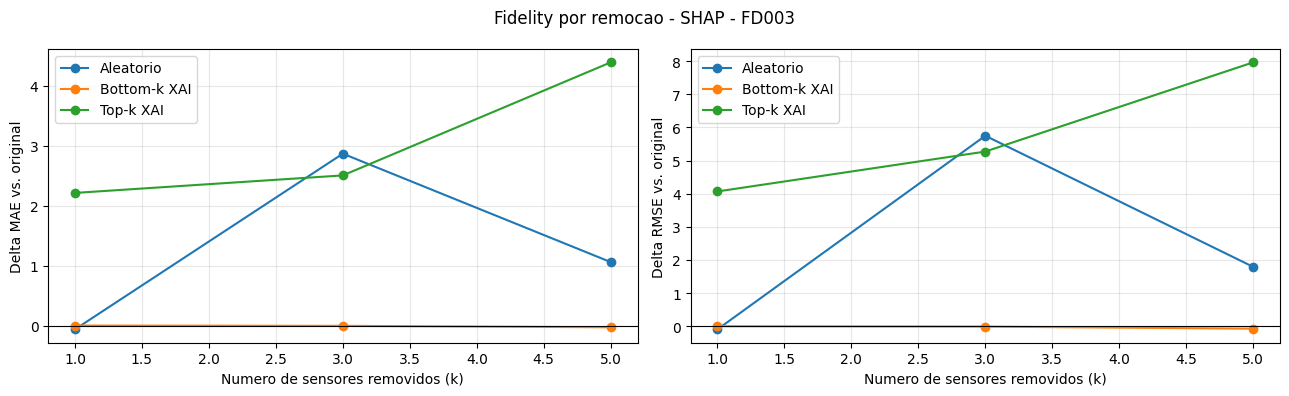

In [6]:
X_train_fd003 = np.load("../../data/processed_data/X_train_FD003.npz")["dados"]
referencia_fd003 = np.median(X_train_fd003, axis=(0, 1))

shap_fd003 = ShapExplainer(model_path_003, x_path_003, y_path_003, background_size=100)
resultados_fidelity_shap_fd003, metricas_originais_fd003, ranking_shap_fd003 = avaliar_fidelity(
    explainer=shap_fd003, X=shap_fd003.X_test, y=shap_fd003.y_test,
    referencia=referencia_fd003, k_values=(1, 3, 5), num_amostras_explicacao=1000
)

print("Métricas sem remoção:", metricas_originais_fd003)
display(ranking_shap_fd003.head(10).round(3))
display(resultados_fidelity_shap_fd003.round(3))
plotar_fidelity(resultados_fidelity_shap_fd003, dataset="FD003", metodo="SHAP")

### FD003

Novamente, a retirada dos sensores mais importantes aumenta consideravelmente as metricas de erro, enquanto a retirada dos menos importantes praticamente nao gera impacto no MAE e RMSE. No teste com `k=3`, a retirada aleatoria ficou levemente pior porque incluiu o `s_12`, que e o sensor mais relevante deste dataset. Mesmo assim, retirando o Top-5 temos o pior resultado geral, demonstrando a fidelity do ranking SHAP.

Métricas sem remoção: {'MAE': np.float64(12.896375828179258), 'RMSE': np.float64(15.928106626038915)}


,Sensor,Importancia media (atribuicao)
0,s_11,23.309
1,s_4,12.121
2,s_9,11.109
3,s_12,7.639
4,s_6,6.470
5,s_7,6.220
6,s_17,5.938
7,s_14,4.725
8,s_3,4.413
9,s_2,3.153


,Estrategia,k sensores removidos,Sensores removidos,MAE,RMSE,Delta MAE vs. original,Delta RMSE vs. original
0,Top-k XAI,1,s_11,14.189,17.613,1.293,1.685
1,Bottom-k XAI,1,s_1,12.896,15.928,0.000,0.000
2,Aleatorio,1,setting_3,12.896,15.928,0.000,0.000
3,Top-k XAI,3,"s_11, s_4, s_9",16.468,21.139,3.572,5.211
4,Bottom-k XAI,3,"s_5, setting_3, s_1",12.896,15.928,0.000,0.000
5,Aleatorio,3,"s_15, s_8, s_13",12.969,15.960,0.072,0.032
6,Top-k XAI,5,"s_11, s_4, s_9, s_12, s_6",16.910,22.647,4.014,6.719
7,Bottom-k XAI,5,"s_18, s_19, s_5, setting_3, s_1",12.896,15.928,0.000,0.000
8,Aleatorio,5,"setting_2, s_12, setting_3, s_2, s_10",13.198,16.074,0.301,0.146


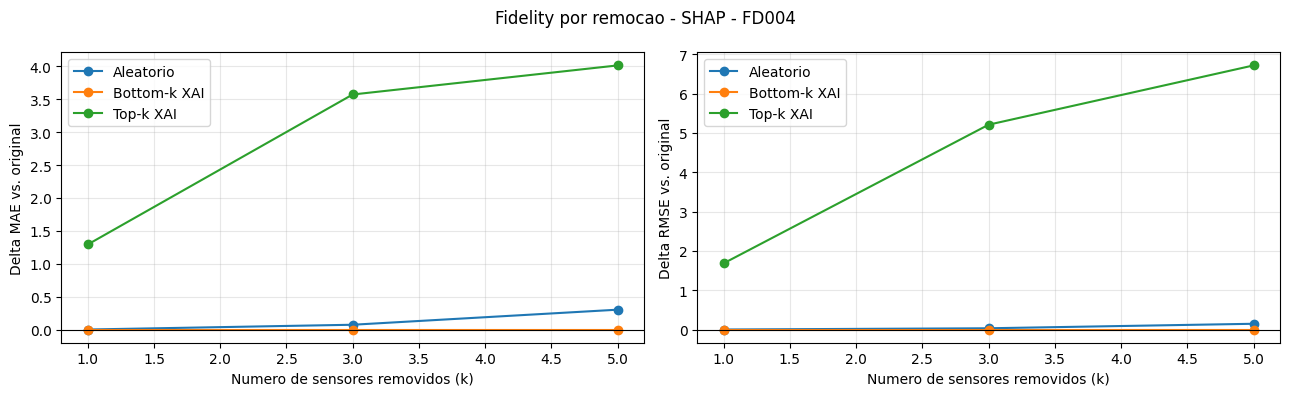

In [7]:
X_train_fd004 = np.load("../../data/processed_data/X_train_FD004.npz")["dados"]
referencia_fd004 = np.median(X_train_fd004, axis=(0, 1))

shap_fd004 = ShapExplainer(model_path_004, x_path_004, y_path_004, background_size=100)
resultados_fidelity_shap_fd004, metricas_originais_fd004, ranking_shap_fd004 = avaliar_fidelity(
    explainer=shap_fd004, X=shap_fd004.X_test, y=shap_fd004.y_test,
    referencia=referencia_fd004, k_values=(1, 3, 5), num_amostras_explicacao=1000
)

print("Métricas sem remoção:", metricas_originais_fd004)
display(ranking_shap_fd004.head(10).round(3))
display(resultados_fidelity_shap_fd004.round(3))
plotar_fidelity(resultados_fidelity_shap_fd004, dataset="FD004", metodo="SHAP")

### FD004

Mesmo sendo o cenario mais complexo, o resultado segue o padrao dos datasets anteriores: a retirada dos sensores mais importantes aumenta bastante o MAE e o RMSE, principalmente com `k=5`. Ja a retirada dos sensores menos importantes nao causa impacto e a retirada aleatoria gera uma variacao muito menor. Dessa forma, a fidelity tambem e comprovada para o FD004.

### Análise geral - Fidelity

Considerando os quatro datasets, os resultados demonstram que o ranking global gerado pelo SHAP possui fidelity, já que ao neutralizar os sensores mais importantes, o MAE e o RMSE aumentam progressivamente e de forma muito superior a retirada dos sensores menos importantes. Os controles aleatorios tambem apresentam impacto menor na maior parte dos testes, quando eles pioram mais o resultado, como no FD003 com `k=3`, isso ocorre por terem incluido sensores do proprio Top-k (como é aleatório pode acontecer). Portanto, as explicacoes identificam sensores que o modelo realmente utiliza para realizar suas previsoes de RUL.

## 2. **Infidelity**: A explicação realmente representa o modelo?

Referências:

https://captum.ai/api/metrics.html

https://scikit-learn.org/stable/modules/model_evaluation.html#r2-score

O LIME gera uma explicação local para cada janela, atribuindo um peso a cada combinação sensor x ciclo. Em seguida, criamos pequenas perturbações na mesma janela e comparamos duas quantidades: a mudança real do RUL previsto pelo modelo e a mudanca estimada pelos pesos do LIME. A infidelity e o erro quadratico medio entre elas, de forma que quanto menor o valor, melhor a explicação representa o comportamento local do modelo.

In [10]:
def vetor_atribuicoes_lime(explicacao_lime, formato_entrada):
    """Reconstrói os pesos do LIME no mesmo formato sensor x ciclo da entrada."""
    n_tempo, n_sensores = formato_entrada
    pesos = np.zeros(n_tempo * n_sensores)
    rotulo = next(iter(explicacao_lime.local_exp))
    for indice, peso in explicacao_lime.local_exp[rotulo]:
        pesos[int(indice)] = peso
    return pesos

def avaliar_infidelity_lime(explainer, num_instancias=30, num_perturbacoes=30, sigma=0.05, num_amostras_lime=2000, seed=42):
    """
    Mede se a mudança prevista pelos pesos locais do LIME acompanha a mudanca real do modelo sob pequenas perturbações.
    """
    rng = np.random.default_rng(seed)
    n = min(num_instancias, len(explainer.X_test))
    n_tempo, n_sensores = explainer.X_test.shape[1:]
    total_features = n_tempo * n_sensores
    escala = np.asarray(explainer.explainer.scaler.scale_).copy()
    escala[escala == 0] = 1.0
    resultados = []

    for indice in range(n):
        x = explainer.X_test[indice].astype(np.float32)
        explicacao = explainer.explain_instance(
            indice, num_features=total_features, num_samples=num_amostras_lime
        )
        pesos = vetor_atribuicoes_lime(explicacao, (n_tempo, n_sensores))

        perturbacoes = rng.normal(0, sigma, size=(num_perturbacoes, n_tempo, n_sensores))
        x_perturbado = x[None, :, :] - perturbacoes
        mudanca_real = (
            explainer.model.predict(x[None, :, :], verbose=0).reshape(-1)[0]
            - explainer.model.predict(x_perturbado, verbose=0).reshape(-1)
        )

        perturbacoes_lime = perturbacoes.transpose(0, 2, 1).reshape(num_perturbacoes, -1)
        mudanca_estimada = (perturbacoes_lime / escala) @ pesos
        infidelity = np.mean((mudanca_estimada - mudanca_real) ** 2)

        resultados.append({
            "Amostra": indice,
            "RUL previsto": explainer.model.predict(x[None, :, :], verbose=0).reshape(-1)[0],
            "Infidelity": infidelity,
            "Fidelidade local do LIME (R2)": explicacao.score,
        })

    resultados = pd.DataFrame(resultados)
    resumo = resultados[["Infidelity", "Fidelidade local do LIME (R2)"]].agg(["mean", "std", "median"])
    return resultados, resumo


In [11]:
lime_fd001 = LimeExplainer(
    model_path_001, x_path_001, y_path_001,
    background_size=500, discretize_continuous=False, random_state=42
)
resultados_infidelity_fd001, resumo_infidelity_fd001 = avaliar_infidelity_lime(
    lime_fd001, num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42
)

display(resumo_infidelity_fd001.round(4))

,Infidelity,Fidelidade local do LIME (R2)
mean,109.4719,0.8816
std,54.2146,0.0054
median,86.7587,0.8813


### Analise - FD001

O LIME obteve R2 local uma média de 0.882, indicando que sua aproximação linear representa bem as previsões do modelo na vizinhança das janelas analisadas. A infidelity teve média de 109.47, com mediana de 86.76, resultado que vamos comparar com os próximos datasets.

In [12]:
lime_fd002 = LimeExplainer(
    model_path_002, x_path_002, y_path_002,
    background_size=500, discretize_continuous=False, random_state=42
)
resultados_infidelity_fd002, resumo_infidelity_fd002 = avaliar_infidelity_lime(
    lime_fd002, num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42
)
display(resumo_infidelity_fd002.round(4))

,Infidelity,Fidelidade local do LIME (R2)
mean,85.4833,0.8503
std,50.6258,0.0065
median,77.8860,0.8493


### Analise - FD002

O FD002 apresentou média de infidelity de 85.48, menor que a observada no FD001. O R2 local obteve média de 0.85, que mostra que o LIME continua aproximando bem o comportamento do modelo nas janelas analisadas. Portanto, para este dataset, os pesos do LIME acompanham de forma consistente as pequenas variações na previsao do RUL.

In [13]:
lime_fd003 = LimeExplainer(
    model_path_003, x_path_003, y_path_003,
    background_size=500, discretize_continuous=False, random_state=42
)
resultados_infidelity_fd003, resumo_infidelity_fd003 = avaliar_infidelity_lime(
    lime_fd003, num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42
)
display(resumo_infidelity_fd003.round(4))

,Infidelity,Fidelidade local do LIME (R2)
mean,237.0377,0.8747
std,128.5568,0.0055
median,191.1138,0.8749


### Analise - FD003

O FD003 apresentou a maior média infidelity, com 237.04, indicando maior diferença entre a mudança estimada pelo LIME e a mudança real do modelo, com as pertubações. Mesmo assim, o R2 local de 0.875 permanece alto, mostrando que o modelo linear local se ajusta bem as janelas. A maior complexidade associada aos dois modos de falha pode tornar as respostas do modelo mais difíceis de representar, logo com pequenas mudanças o modelo pode acabar tendo um infidelity maior.

In [14]:
lime_fd004 = LimeExplainer(
    model_path_004, x_path_004, y_path_004,
    background_size=500, discretize_continuous=False, random_state=42
)
resultados_infidelity_fd004, resumo_infidelity_fd004 = avaliar_infidelity_lime(
    lime_fd004, num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42
)
display(resumo_infidelity_fd004.round(4))

,Infidelity,Fidelidade local do LIME (R2)
mean,17.2002,0.6903
std,3.3590,0.0105
median,16.7000,0.6905


### Análise - FD004

O FD004 apresentou a menor infidelity média, 17.20. Isso é numericamente coerente, mas não permite concluir sozinho que o LIME é melhor neste dataset: como a infidelity é um erro absoluto, ela também fica baixa se o modelo variar pouco diante das perturbações pequenas usadas no teste. O R² local médio de 0.69, inferior aos outros datasets, mostra que a aproximação linear do LIME foi menos precisa, então as duas métricas devem ser interpretadas em conjunto.

### Análise geral - Infidelity

No geral, o LIME apresentou R2 local alto em FD001, FD002 e FD003, indicando que suas explicações lineares locais representam bem o comportamento da rede nas janelas analisadas. A infidelity variou entre os datasets, sendo maior no FD003 e menor no FD004. Essas métricas devem ser avaliadas juntas: a infidelity mede o erro ao prever pequenas mudanças na saída, enquanto o R2 mede a qualidade do ajuste linear local. Assim, os resultados mostram que a qualidade da explicação depende do dataset e da perturbação, sem permitir concluir apenas pela infidelity que um modelo é mais explicável que outro.

## 3. **Stability**: Mudanças pequenas nos dados, explicação muda pouco?

### Ideia para responder:

Vamos selecionar janelas reais de teste, e criar uma versão levemente perturbada de cada janela, aplicando um pequeno ruído nas variáveis. Então vamos gerar o SHAP para janela original e pertubada para comparar as explicações. Vamos avaliar o top 5 sensores mais importantes, e também um ranking completo fazendo uma correlação entre os dois rankings. 

In [3]:
def calcular_shap_lote(explainer, X):
    valores = explainer.explainer.shap_values(X.astype(np.float32))
    if isinstance(valores, list):
        valores = valores[0]
    valores = np.asarray(valores)
    return valores[..., 0] if valores.ndim == 4 else valores

def correlacao_spearman(valores_a, valores_b):
    ranking_a = pd.Series(valores_a).rank(ascending=False, method='average')
    ranking_b = pd.Series(valores_b).rank(ascending=False, method='average')
    return ranking_a.corr(ranking_b, method='spearman')

def avaliar_stability_shap(explainer, X_train, num_instancias=100, proporcao_ruido=0.05, top_k=5, seed=42):
    rng = np.random.default_rng(seed)
    n = min(num_instancias, len(explainer.X_test))
    indices = np.sort(rng.choice(len(explainer.X_test), size=n, replace=False))
    X_original = explainer.X_test[indices].astype(np.float32)

    desvio_sensor = np.std(X_train, axis=(0, 1))
    escala_ruido = proporcao_ruido * np.where(desvio_sensor == 0, 1.0, desvio_sensor)
    ruido = rng.normal(0, escala_ruido, size=X_original.shape).astype(np.float32)
    X_perturbado = X_original + ruido

    shap_original = calcular_shap_lote(explainer, X_original)
    shap_perturbado = calcular_shap_lote(explainer, X_perturbado)
    importancia_original = np.sum(np.abs(shap_original), axis=1)
    importancia_perturbada = np.sum(np.abs(shap_perturbado), axis=1)
    pred_original = explainer.model.predict(X_original, verbose=0).reshape(-1)
    pred_perturbada = explainer.model.predict(X_perturbado, verbose=0).reshape(-1)

    resultados = []
    for posicao, indice in enumerate(indices):
        imp_a, imp_b = importancia_original[posicao], importancia_perturbada[posicao]
        top_a = set(np.argsort(imp_a)[-top_k:])
        top_b = set(np.argsort(imp_b)[-top_k:])
        resultados.append({
            'Amostra': indice,
            'Top-1 manteve': int(np.argmax(imp_a) == np.argmax(imp_b)),
            f'Sensores em comum no Top-{top_k}': len(top_a & top_b),
            f'Proporcao em comum no Top-{top_k}': len(top_a & top_b) / top_k,
            'Correlacao de Spearman': correlacao_spearman(imp_a, imp_b),
            'Variacao absoluta da previsao de RUL': abs(pred_original[posicao] - pred_perturbada[posicao]),
        })

    resultados = pd.DataFrame(resultados)
    global_a = importancia_original.mean(axis=0)
    global_b = importancia_perturbada.mean(axis=0)
    ordem_a, ordem_b = np.argsort(global_a)[::-1], np.argsort(global_b)[::-1]
    resumo = {
        f'Top-{top_k} global original': ', '.join(explainer.feature_names[ordem_a[:top_k]]),
        f'Top-{top_k} global perturbado': ', '.join(explainer.feature_names[ordem_b[:top_k]]),
        f'Sensores em comum no Top-{top_k} global': len(set(ordem_a[:top_k]) & set(ordem_b[:top_k])),
        'Correlacao de Spearman global': correlacao_spearman(global_a, global_b),
    }
    importancias = pd.DataFrame({
        'Sensor': explainer.feature_names,
        'Importancia SHAP original': global_a,
        'Importancia SHAP perturbada': global_b,
    }).sort_values('Importancia SHAP original', ascending=False)
    return resultados, resumo, importancias

def plotar_stability(importancias, dataset, top_n=10):
    dados = importancias.head(top_n).iloc[::-1]
    y = np.arange(len(dados))
    plt.figure(figsize=(9, 5))
    plt.barh(y - 0.18, dados['Importancia SHAP original'], height=0.36, label='Original')
    plt.barh(y + 0.18, dados['Importancia SHAP perturbada'], height=0.36, label='Perturbada')
    plt.yticks(y, dados['Sensor'])
    plt.xlabel('Importancia media absoluta do SHAP')
    plt.title(f'Estabilidade das importancias SHAP - {dataset}')
    plt.grid(axis='x', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

,FD001
Top-5 global original,"s_11, s_12, s_7, s_15, s_4"
Top-5 global perturbado,"s_11, s_12, s_7, s_15, s_4"
Sensores em comum no Top-5 global,5
Correlacao de Spearman global,0.989908


,count,mean,std,min,25%,50%,75%,max
Amostra,1000.0,5169.376,2945.516,40.000,2641.000,5119.000,7728.000,10161.000
Top-1 manteve,1000.0,0.919,0.273,0.000,1.000,1.000,1.000,1.000
Sensores em comum no Top-5,1000.0,4.859,0.354,3.000,5.000,5.000,5.000,5.000
Proporcao em comum no Top-5,1000.0,0.972,0.071,0.600,1.000,1.000,1.000,1.000
Correlacao de Spearman,1000.0,0.984,0.009,0.944,0.980,0.986,0.991,0.998
Variacao absoluta da previsao de RUL,1000.0,1.083,1.258,0.000,0.253,0.649,1.458,8.321


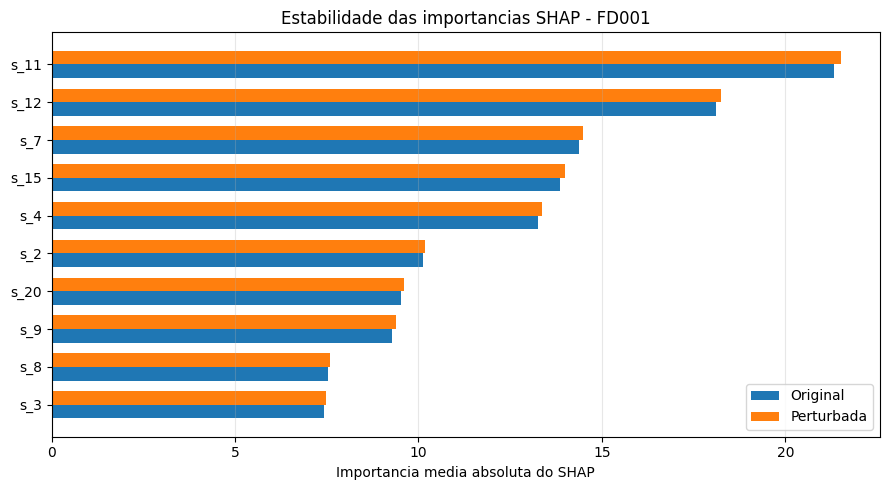

In [8]:
X_train_fd001 = np.load("../../data/processed_data/X_train_FD001.npz")["dados"]
shap_fd001 = ShapExplainer(model_path_001, x_path_001, y_path_001, background_size=100)

resultados_stability_fd001, resumo_stability_fd001, importancias_stability_fd001 = avaliar_stability_shap(
    shap_fd001, X_train_fd001, num_instancias=1000, proporcao_ruido=0.1, top_k=5, seed=42
)

display(pd.DataFrame([resumo_stability_fd001]).T.rename(columns={0: 'FD001'}).round(3))
display(resultados_stability_fd001.describe().T.round(3))
plotar_stability(importancias_stability_fd001, dataset='FD001', top_n=10)

### Analise - FD001

O FD001 apresentou alta estabilidade. O Top-5 global foi exatamente igual antes e depois da perturbação e a correlação global de Spearman foi de 0,990. Portanto, mesmo com ruído de 10%, as explicações SHAP permaneceram praticamente inalteradas.

,FD002
Top-5 global original,"s_11, s_15, s_4, s_7, s_2"
Top-5 global perturbado,"s_11, s_15, s_4, s_7, s_2"
Sensores em comum no Top-5 global,5
Correlacao de Spearman global,0.994769


,count,mean,std,min,25%,50%,75%,max
Amostra,1000.0,13350.714,7679.260,112.000,6518.000,13432.500,20084.500,26490.000
Top-1 manteve,1000.0,0.977,0.150,0.000,1.000,1.000,1.000,1.000
Sensores em comum no Top-5,1000.0,4.807,0.397,3.000,5.000,5.000,5.000,5.000
Proporcao em comum no Top-5,1000.0,0.961,0.079,0.600,1.000,1.000,1.000,1.000
Correlacao de Spearman,1000.0,0.983,0.008,0.938,0.980,0.985,0.989,0.996
Variacao absoluta da previsao de RUL,1000.0,1.181,1.310,0.001,0.303,0.765,1.586,11.703


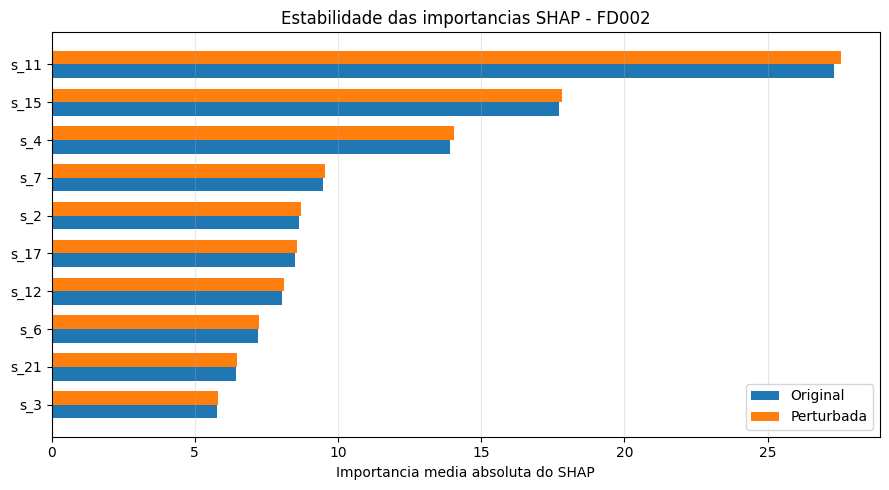

In [9]:
X_train_fd002 = np.load('../../data/processed_data/X_train_FD002.npz')['dados']
shap_fd002 = ShapExplainer(model_path_002, x_path_002, y_path_002, background_size=100)

resultados_stability_fd002, resumo_stability_fd002, importancias_stability_fd002 = avaliar_stability_shap(
    shap_fd002, X_train_fd002, num_instancias=1000, proporcao_ruido=0.10, top_k=5, seed=42
)

display(pd.DataFrame([resumo_stability_fd002]).T.rename(columns={0: 'FD002'}).round(3))
display(resultados_stability_fd002.describe().T.round(3))
plotar_stability(importancias_stability_fd002, dataset='FD002', top_n=10)

### Analise - FD002

O FD002 também apresentou estabilidade muito alta. O Top-5 global foi preservado integralmente e a correlação global de Spearman foi de 0,995. Logo, pequenas perturbações nos sinais quase não alteram o ranking do SHAP.

,FD003
Top-5 global original,"s_12, s_6, s_7, s_11, s_13"
Top-5 global perturbado,"s_12, s_6, s_7, s_11, s_13"
Sensores em comum no Top-5 global,5
Correlacao de Spearman global,0.986085


,count,mean,std,min,25%,50%,75%,max
Amostra,1000.0,6858.219,3922.309,56.000,3492.500,6869.000,10283.500,13693.000
Top-1 manteve,1000.0,0.978,0.147,0.000,1.000,1.000,1.000,1.000
Sensores em comum no Top-5,1000.0,4.751,0.446,3.000,5.000,5.000,5.000,5.000
Proporcao em comum no Top-5,1000.0,0.950,0.089,0.600,1.000,1.000,1.000,1.000
Correlacao de Spearman,1000.0,0.942,0.036,0.810,0.916,0.943,0.977,0.998
Variacao absoluta da previsao de RUL,1000.0,1.751,2.196,0.002,0.366,0.974,2.226,14.529


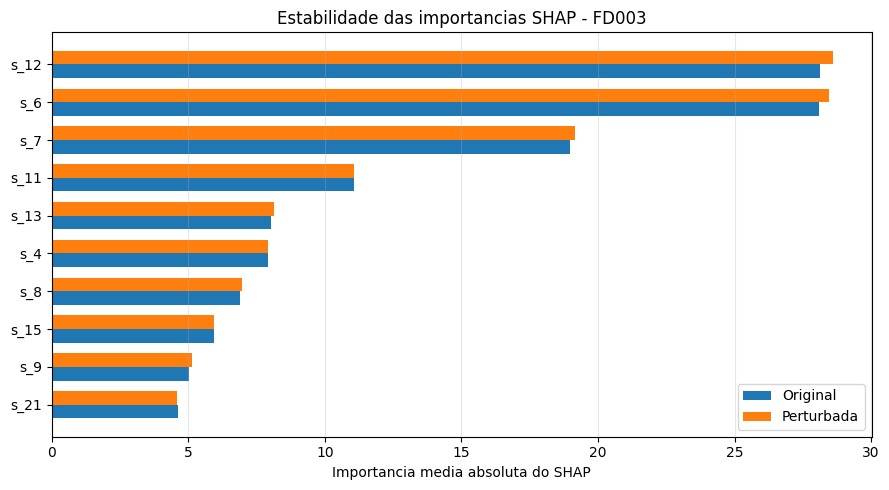

In [10]:
X_train_fd003 = np.load('../../data/processed_data/X_train_FD003.npz')['dados']
shap_fd003 = ShapExplainer(model_path_003, x_path_003, y_path_003, background_size=100)

resultados_stability_fd003, resumo_stability_fd003, importancias_stability_fd003 = avaliar_stability_shap(
    shap_fd003, X_train_fd003, num_instancias=1000, proporcao_ruido=0.10, top_k=5, seed=42
)

display(pd.DataFrame([resumo_stability_fd003]).T.rename(columns={0: 'FD003'}).round(3))
display(resultados_stability_fd003.describe().T.round(3))
plotar_stability(importancias_stability_fd003, dataset='FD003', top_n=10)

### Analise - FD003

No FD003, o Top-5 global também foi idêntico antes e depois do ruído, com correlação global de Spearman de 0,986. Apesar de ser o menor resultado entre os quatro cenários, os valores continuam altos e indicam boa estabilidade das explicações.

,FD004
Top-5 global original,"s_11, s_9, s_4, s_12, s_6"
Top-5 global perturbado,"s_11, s_9, s_4, s_12, s_6"
Sensores em comum no Top-5 global,5
Correlacao de Spearman global,0.995643


,count,mean,std,min,25%,50%,75%,max
Amostra,1000.0,17155.550,9848.576,145.000,8436.250,17248.000,25841.000,34057.000
Top-1 manteve,1000.0,0.940,0.238,0.000,1.000,1.000,1.000,1.000
Sensores em comum no Top-5,1000.0,4.827,0.394,3.000,5.000,5.000,5.000,5.000
Proporcao em comum no Top-5,1000.0,0.965,0.079,0.600,1.000,1.000,1.000,1.000
Correlacao de Spearman,1000.0,0.974,0.019,0.866,0.968,0.980,0.987,0.996
Variacao absoluta da previsao de RUL,1000.0,1.018,1.603,0.000,0.115,0.381,1.240,16.326


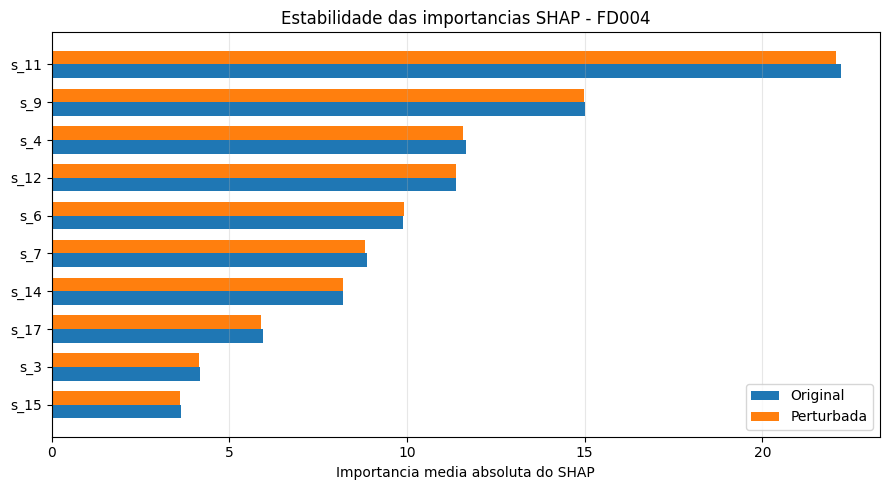

In [11]:
X_train_fd004 = np.load('../../data/processed_data/X_train_FD004.npz')['dados']
shap_fd004 = ShapExplainer(model_path_004, x_path_004, y_path_004, background_size=100)

resultados_stability_fd004, resumo_stability_fd004, importancias_stability_fd004 = avaliar_stability_shap(
    shap_fd004, X_train_fd004, num_instancias=1000, proporcao_ruido=0.10, top_k=5, seed=42
)

display(pd.DataFrame([resumo_stability_fd004]).T.rename(columns={0: 'FD004'}).round(3))
display(resultados_stability_fd004.describe().T.round(3))
plotar_stability(importancias_stability_fd004, dataset='FD004', top_n=10)

### Analise - FD004

O FD004 apresentou uma estabilidade muito alta, mesmo sendo o cenário mais complexo. O Top-5 global se manteve igual e a correlação global de Spearman chegou a 0,996. Isso mostra que a complexidade adicional do FD004 não tornou as explicações SHAP instáveis.

### Análise geral - Stability

Os quatro datasets apresentaram alta estabilidade das explicações SHAP. Em todos os casos, os cinco sensores mais importantes na análise global foram os mesmos antes e depois da perturbação. As correlações globais de Spearman ficaram entre 0,986 e 0,996. Logo, para ruído gaussiano de 10% do desvio-padrão dos sensores, pequenas alterações nos dados não modificam de forma relevante o ranking produzido pelo SHAP.

## 4. **Sparsity**: Quantas variáveis são necessárias para explicar?

Vamos manter apenas os sensores mais importantes do ranking global SHAP e mascarar todos os demais com a mediana do conjunto de treinamento. O menor número de sensores cujo MAE permanece até 5% acima do MAE original será considerado suficiente para representar a previsão de forma esparsa.

In [12]:
def avaliar_sparsity_shap(explainer, X_train, k_values=(1, 3, 5, 7, 10, 15), num_amostras_explicacao=1000, tolerancia_mae=0.05):
    referencia = np.median(X_train, axis=(0, 1))
    n = min(num_amostras_explicacao, len(explainer.X_test))
    valores_shap = explainer.explainer.shap_values(explainer.X_test[:n].astype(np.float32))
    if isinstance(valores_shap, list):
        valores_shap = valores_shap[0]
    valores_shap = np.asarray(valores_shap)
    valores_shap = valores_shap[..., 0] if valores_shap.ndim == 4 else valores_shap
    importancia = np.mean(np.sum(np.abs(valores_shap), axis=1), axis=0)
    ranking = np.argsort(importancia)[::-1]

    X = explainer.X_test
    y = explainer.y_test
    predicao_original = explainer.model.predict(X, verbose=0).reshape(-1)
    mae_original = np.mean(np.abs(y.reshape(-1) - predicao_original))
    limite_mae = mae_original * (1 + tolerancia_mae)
    resultados = []
    for k in sorted(set(k_values) | {X.shape[2]}):
        sensores_mantidos = ranking[:k]
        sensores_mascarados = np.setdiff1d(np.arange(X.shape[2]), sensores_mantidos)
        X_reduzido = X.copy()
        X_reduzido[:, :, sensores_mascarados] = referencia[sensores_mascarados]
        predicao = explainer.model.predict(X_reduzido, verbose=0).reshape(-1)
        mae = np.mean(np.abs(y.reshape(-1) - predicao))
        rmse = np.sqrt(np.mean((y.reshape(-1) - predicao) ** 2))
        resultados.append({
            'Sensores mantidos (k)': k,
            'Sensores mantidos': ', '.join(explainer.feature_names[sensores_mantidos]),
            'MAE': mae,
            'RMSE': rmse,
            'Aumento percentual do MAE': 100 * (mae - mae_original) / mae_original,
            'Dentro da tolerancia de 5%': mae <= limite_mae,
        })
    resultados = pd.DataFrame(resultados).sort_values('Sensores mantidos (k)')
    suficiente = resultados[resultados['Dentro da tolerancia de 5%']].head(1)
    return resultados, mae_original, limite_mae, suficiente

def plotar_sparsity(resultados, mae_original, limite_mae, dataset):
    plt.figure(figsize=(8, 4))
    plt.plot(resultados['Sensores mantidos (k)'], resultados['MAE'], marker='o')
    plt.axhline(mae_original, color='black', linestyle='--', label='MAE original')
    plt.axhline(limite_mae, color='tab:red', linestyle='--', label='Limite de 5%')
    plt.xlabel('Numero de sensores mantidos (Top-k SHAP)')
    plt.ylabel('MAE')
    plt.title(f'Sparsity - SHAP - {dataset}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

MAE original: 10.097
Limite de MAE (5%): 10.601


,Sensores mantidos (k),Sensores mantidos,MAE,RMSE,Aumento percentual do MAE,Dentro da tolerancia de 5%
0,1,s_11,19.254,31.251,90.698,False
1,2,"s_11, s_12",18.640,29.065,84.614,False
2,3,"s_11, s_12, s_7",17.637,26.344,74.684,False
3,4,"s_11, s_12, s_7, s_15",16.290,23.544,61.343,False
4,5,"s_11, s_12, s_7, s_15, s_4",14.651,20.458,45.103,False
5,6,"s_11, s_12, s_7, s_15, s_4, s_2",13.691,18.749,35.595,False
6,7,"s_11, s_12, s_7, s_15, s_4, s_2, s_20",12.715,17.347,25.937,False
7,8,"s_11, s_12, s_7, s_15, s_4, s_2, s_20, s_3",12.184,16.547,20.669,False
8,9,"s_11, s_12, s_7, s_15, s_4, s_2, s_20, s_3, s_8",11.764,15.959,16.513,False
9,10,"s_11, s_12, s_7, s_15, s_4, s_2, s_20, s_3, s_...",11.385,15.493,12.761,False


,Sensores mantidos (k),Sensores mantidos,MAE,RMSE,Aumento percentual do MAE,Dentro da tolerancia de 5%
11,12,"s_11, s_12, s_7, s_15, s_4, s_2, s_20, s_3, s_...",10.339,14.371,2.396,True


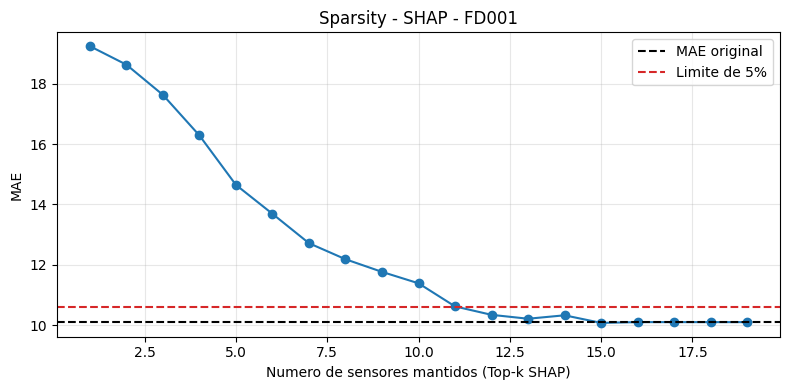

In [13]:
X_train_fd001 = np.load('../../data/processed_data/X_train_FD001.npz')['dados']
shap_fd001 = ShapExplainer(model_path_001, x_path_001, y_path_001, background_size=100)

resultados_sparsity_fd001, mae_original_fd001, limite_mae_fd001, suficiente_fd001 = avaliar_sparsity_shap(
    shap_fd001, X_train_fd001, k_values=range(1, shap_fd001.X_test.shape[2] + 1),
    num_amostras_explicacao=1000, tolerancia_mae=0.05
)

print(f'MAE original: {mae_original_fd001:.3f}')
print(f'Limite de MAE (5%): {limite_mae_fd001:.3f}')
display(resultados_sparsity_fd001.round(3))
display(suficiente_fd001.round(3))
plotar_sparsity(resultados_sparsity_fd001, mae_original_fd001, limite_mae_fd001, dataset='FD001')

### Análise - FD001

No FD001, foram necessários 12 dos 19 sensores para manter o MAE dentro do limite de 5%. Com esse subconjunto, o MAE foi 10,339, apenas 2,4% acima do resultado original (10,097). Então, é possível reduzir o número de sensores, mas o modelo ainda depende de uma quantidade considerável de sensores para preservar seu desempenho.

MAE original: 12.255
Limite de MAE (5%): 12.868


,Sensores mantidos (k),Sensores mantidos,MAE,RMSE,Aumento percentual do MAE,Dentro da tolerancia de 5%
0,1,s_11,21.441,28.087,74.960,False
1,2,"s_11, s_15",18.381,22.860,49.987,False
2,3,"s_11, s_15, s_4",16.309,19.872,33.082,False
3,4,"s_11, s_15, s_4, s_7",15.429,18.965,25.897,False
4,5,"s_11, s_15, s_4, s_7, s_2",14.535,18.182,18.604,False
5,6,"s_11, s_15, s_4, s_7, s_2, s_17",13.761,17.497,12.290,False
6,7,"s_11, s_15, s_4, s_7, s_2, s_17, s_12",13.502,17.437,10.173,False
7,8,"s_11, s_15, s_4, s_7, s_2, s_17, s_12, s_6",13.434,17.304,9.624,False
8,9,"s_11, s_15, s_4, s_7, s_2, s_17, s_12, s_6, s_21",13.317,17.300,8.665,False
9,10,"s_11, s_15, s_4, s_7, s_2, s_17, s_12, s_6, s_...",13.163,17.270,7.409,False


,Sensores mantidos (k),Sensores mantidos,MAE,RMSE,Aumento percentual do MAE,Dentro da tolerancia de 5%
13,14,"s_11, s_15, s_4, s_7, s_2, s_17, s_12, s_6, s_...",12.844,16.839,4.809,True


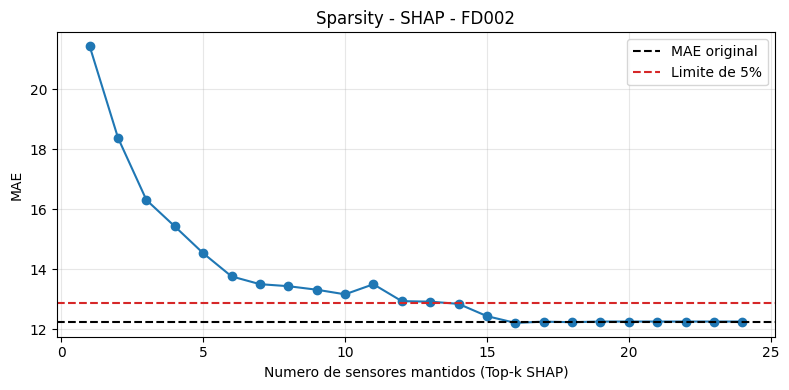

In [14]:
X_train_fd002 = np.load('../../data/processed_data/X_train_FD002.npz')['dados']
shap_fd002 = ShapExplainer(model_path_002, x_path_002, y_path_002, background_size=100)

resultados_sparsity_fd002, mae_original_fd002, limite_mae_fd002, suficiente_fd002 = avaliar_sparsity_shap(
    shap_fd002, X_train_fd002, k_values=range(1, shap_fd002.X_test.shape[2] + 1),
    num_amostras_explicacao=1000, tolerancia_mae=0.05
)

print(f'MAE original: {mae_original_fd002:.3f}')
print(f'Limite de MAE (5%): {limite_mae_fd002:.3f}')
display(resultados_sparsity_fd002.round(3))
display(suficiente_fd002.round(3))
plotar_sparsity(resultados_sparsity_fd002, mae_original_fd002, limite_mae_fd002, dataset='FD002')

### Análise - FD002

No FD002, o menor subconjunto que respeitou a tolerância foi de 14 dos 24 sensores. O MAE ficou em 12,844, aumento de 4,8% em relação ao valor original de 12,255. Assim, o modelo pode operar com pouco mais da metade dos sensores sem perda relevante de desempenho, mas não é suficiente manter apenas os cinco principais.

MAE original: 7.110
Limite de MAE (5%): 7.465


,Sensores mantidos (k),Sensores mantidos,MAE,RMSE,Aumento percentual do MAE,Dentro da tolerancia de 5%
0,1,s_12,14.107,22.034,98.421,False
1,2,"s_12, s_6",14.402,23.395,102.580,False
2,3,"s_12, s_6, s_7",12.071,19.627,69.788,False
3,4,"s_12, s_6, s_7, s_11",11.103,17.733,56.175,False
4,5,"s_12, s_6, s_7, s_11, s_4",10.099,15.819,42.049,False
5,6,"s_12, s_6, s_7, s_11, s_4, s_13",9.681,15.069,36.172,False
6,7,"s_12, s_6, s_7, s_11, s_4, s_13, s_8",9.556,14.609,34.413,False
7,8,"s_12, s_6, s_7, s_11, s_4, s_13, s_8, s_15",9.239,14.245,29.950,False
8,9,"s_12, s_6, s_7, s_11, s_4, s_13, s_8, s_15, s_21",8.608,12.997,21.074,False
9,10,"s_12, s_6, s_7, s_11, s_4, s_13, s_8, s_15, s_...",8.144,12.105,14.548,False


,Sensores mantidos (k),Sensores mantidos,MAE,RMSE,Aumento percentual do MAE,Dentro da tolerancia de 5%
11,12,"s_12, s_6, s_7, s_11, s_4, s_13, s_8, s_15, s_...",7.2,10.995,1.269,True


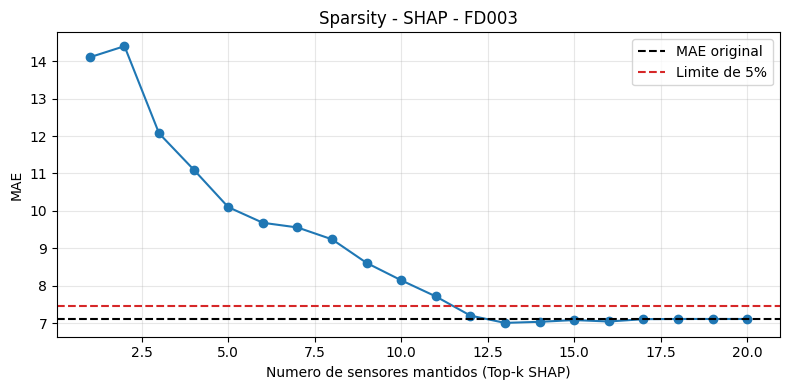

In [15]:
X_train_fd003 = np.load('../../data/processed_data/X_train_FD003.npz')['dados']
shap_fd003 = ShapExplainer(model_path_003, x_path_003, y_path_003, background_size=100)

resultados_sparsity_fd003, mae_original_fd003, limite_mae_fd003, suficiente_fd003 = avaliar_sparsity_shap(
    shap_fd003, X_train_fd003, k_values=range(1, shap_fd003.X_test.shape[2] + 1),
    num_amostras_explicacao=1000, tolerancia_mae=0.05
)

print(f'MAE original: {mae_original_fd003:.3f}')
print(f'Limite de MAE (5%): {limite_mae_fd003:.3f}')
display(resultados_sparsity_fd003.round(3))
display(suficiente_fd003.round(3))
plotar_sparsity(resultados_sparsity_fd003, mae_original_fd003, limite_mae_fd003, dataset='FD003')

### Análise - FD003

No FD003, 12 dos 20 sensores foram suficientes para respeitar o limite de 5%. O MAE obtido foi 7,200, apenas 1,3% acima do MAE original de 7,110, e tendo um salto muito grande quando retiramos o próximo sensor. Isso indica que uma parte dos sensores possui contribuição prática e sendo importantes para manter o erro mais baixo.

MAE original: 12.896
Limite de MAE (5%): 13.541


,Sensores mantidos (k),Sensores mantidos,MAE,RMSE,Aumento percentual do MAE,Dentro da tolerancia de 5%
0,1,s_11,17.167,23.176,33.113,False
1,2,"s_11, s_4",15.894,20.586,23.242,False
2,3,"s_11, s_4, s_9",14.776,18.713,14.576,False
3,4,"s_11, s_4, s_9, s_12",14.652,18.406,13.616,False
4,5,"s_11, s_4, s_9, s_12, s_6",14.759,18.351,14.441,False
5,6,"s_11, s_4, s_9, s_12, s_6, s_7",14.366,17.691,11.399,False
6,7,"s_11, s_4, s_9, s_12, s_6, s_7, s_17",13.885,17.015,7.669,False
7,8,"s_11, s_4, s_9, s_12, s_6, s_7, s_17, s_14",13.546,16.702,5.041,False
8,9,"s_11, s_4, s_9, s_12, s_6, s_7, s_17, s_14, s_3",13.284,16.381,3.004,True
9,10,"s_11, s_4, s_9, s_12, s_6, s_7, s_17, s_14, s_...",13.096,16.149,1.545,True


,Sensores mantidos (k),Sensores mantidos,MAE,RMSE,Aumento percentual do MAE,Dentro da tolerancia de 5%
8,9,"s_11, s_4, s_9, s_12, s_6, s_7, s_17, s_14, s_3",13.284,16.381,3.004,True


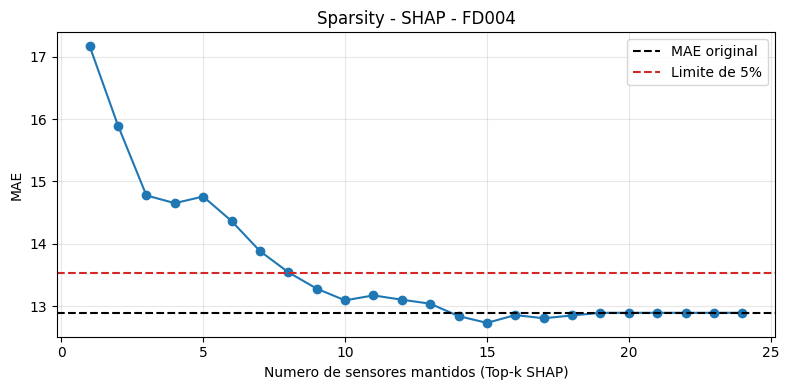

In [16]:
X_train_fd004 = np.load('../../data/processed_data/X_train_FD004.npz')['dados']
shap_fd004 = ShapExplainer(model_path_004, x_path_004, y_path_004, background_size=100)

resultados_sparsity_fd004, mae_original_fd004, limite_mae_fd004, suficiente_fd004 = avaliar_sparsity_shap(
    shap_fd004, X_train_fd004, k_values=range(1, shap_fd004.X_test.shape[2] + 1),
    num_amostras_explicacao=1000, tolerancia_mae=0.05
)

print(f'MAE original: {mae_original_fd004:.3f}')
print(f'Limite de MAE (5%): {limite_mae_fd004:.3f}')
display(resultados_sparsity_fd004.round(3))
display(suficiente_fd004.round(3))
plotar_sparsity(resultados_sparsity_fd004, mae_original_fd004, limite_mae_fd004, dataset='FD004')

### Análise - FD004

O FD004 apresentou o resultado mais esparso: apenas 9 dos 24 sensores mantiveram o MAE dentro da tolerância. O MAE foi 13,284, aumento de 3,0% em relação ao original de 12,896. Portanto, mesmo no cenário mais complexo, o modelo consegue preservar o desempenho usando uma parcela menor dos sensores.

### Análise geral - Sparsity

Os resultados mostram que os rankings SHAP permitem reduzir o conjunto de sensores, mas cinco variáveis não foram suficientes em nenhum dataset sob a tolerância de 5% no MAE. Os menores subconjuntos suficientes foram: 12 de 19 sensores no FD001, 14 de 24 no FD002, 12 de 20 no FD003 e 9 de 24 no FD004. Assim, o FD004 apresentou a maior sparsity, o que é bastante interessante já que é o modelo mais complexo. Pequenas melhorias de MAE após mascaramento não devem ser interpretadas como ganho real do modelo, pois a substituição pela mediana altera a distribuição de entrada.

## 5. **Completeness**: A explicação cobre toda a decisão?

Ref:

https://adataodyssey.com/axioms-xai/

Para cada janela, a previsão será reconstruída por: **valor-base + soma dos valores SHAP assinados de todos os sensores e ciclos**. A completeness é avaliada pelo erro entre essa reconstrução e a previsão original da CNN-LSTM. Quanto menor o erro, mais completamente as atribuições SHAP representam a decisão numérica do modelo.

In [6]:
def obter_valor_base_shap(explainer):
    valor_base = getattr(explainer.explainer, 'expected_value', None)
    if valor_base is not None:
        return float(np.asarray(valor_base).reshape(-1)[0])
    return float(explainer.model.predict(explainer.background_data, verbose=0).mean())

def avaliar_completeness_shap(explainer, num_instancias=1000):
    n = min(num_instancias, len(explainer.X_test))
    X = explainer.X_test[:n].astype(np.float32)
    predicao_modelo = explainer.model.predict(X, verbose=0).reshape(-1)
    valores_shap = explainer.explainer.shap_values(X)
    if isinstance(valores_shap, list):
        valores_shap = valores_shap[0]
    valores_shap = np.asarray(valores_shap)
    valores_shap = valores_shap[..., 0] if valores_shap.ndim == 4 else valores_shap

    valor_base = obter_valor_base_shap(explainer)
    predicao_reconstruida = valor_base + valores_shap.sum(axis=(1, 2))
    erro = predicao_reconstruida - predicao_modelo
    resultados = pd.DataFrame({
        'Amostra': np.arange(n),
        'RUL previsto pelo modelo': predicao_modelo,
        'RUL reconstruido pelos SHAP': predicao_reconstruida,
        'Erro absoluto de completeness': np.abs(erro),
    })
    resumo = pd.Series({
        'Valor-base': valor_base,
        'MAE de completeness': np.mean(np.abs(erro)),
        'RMSE de completeness': np.sqrt(np.mean(erro ** 2)),
        'Mediana do erro absoluto': np.median(np.abs(erro)),
        'Maior erro absoluto': np.max(np.abs(erro)),
    })
    return resultados, resumo

def plotar_completeness(resultados, dataset):
    limite = max(resultados['RUL previsto pelo modelo'].max(), resultados['RUL reconstruido pelos SHAP'].max())
    plt.figure(figsize=(6, 6))
    plt.scatter(resultados['RUL previsto pelo modelo'], resultados['RUL reconstruido pelos SHAP'], alpha=0.45, s=14)
    plt.plot([0, limite], [0, limite], '--', color='black', label='Reconstrucao perfeita')
    plt.xlabel('RUL previsto pelo modelo')
    plt.ylabel('RUL reconstruido pelos SHAP')
    plt.title(f'Completeness - SHAP - {dataset}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

,FD001
Valor-base,114.7529
MAE de completeness,0.7102
RMSE de completeness,0.9954
Mediana do erro absoluto,0.5076
Maior erro absoluto,4.8301


,Amostra,RUL previsto pelo modelo,RUL reconstruido pelos SHAP,Erro absoluto de completeness
0,0,120.948997,121.2407,0.2917
1,1,120.945297,121.7733,0.8281
2,2,116.083504,117.1336,1.0501
3,3,115.585098,115.4041,0.1810
4,4,113.445396,114.6480,1.2025
5,5,114.971703,115.3348,0.3631
6,6,118.489601,118.3295,0.1601
7,7,120.744698,121.1777,0.4330
8,8,122.616997,122.1678,0.4492
9,9,124.377998,125.3587,0.9807


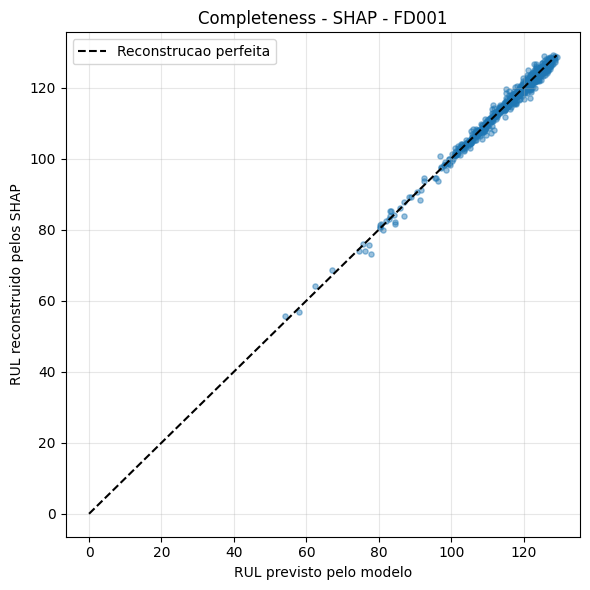

In [7]:
shap_fd001 = ShapExplainer(model_path_001, x_path_001, y_path_001, background_size=100)
resultados_completeness_fd001, resumo_completeness_fd001 = avaliar_completeness_shap(
    shap_fd001, num_instancias=1000
)

display(resumo_completeness_fd001.to_frame('FD001').round(4))
display(resultados_completeness_fd001.head(10).round(4))
plotar_completeness(resultados_completeness_fd001, dataset='FD001')

### Análise - FD001

O FD001 apresentou boa completeness. O MAE de reconstrução foi de 0,710 ciclo de RUL e a mediana do erro absoluto foi de 0,508, valores baixos quando comparados às previsões em torno de 115 ciclos. Assim, a soma do valor-base com as atribuições SHAP reconstrói adequadamente a maior parte das previsões da rede.

,FD002
Valor-base,116.0174
MAE de completeness,0.8391
RMSE de completeness,1.3874
Mediana do erro absoluto,0.4889
Maior erro absoluto,13.6098


,Amostra,RUL previsto pelo modelo,RUL reconstruido pelos SHAP,Erro absoluto de completeness
0,0,120.831200,120.8936,0.0624
1,1,121.658699,121.6043,0.0544
2,2,121.476700,121.4248,0.0519
3,3,121.219803,121.4561,0.2363
4,4,120.799797,120.6754,0.1243
5,5,123.280701,123.3944,0.1137
6,6,123.751602,123.3456,0.4060
7,7,122.812401,122.6486,0.1638
8,8,120.365700,119.8613,0.5044
9,9,117.204903,117.4097,0.2049


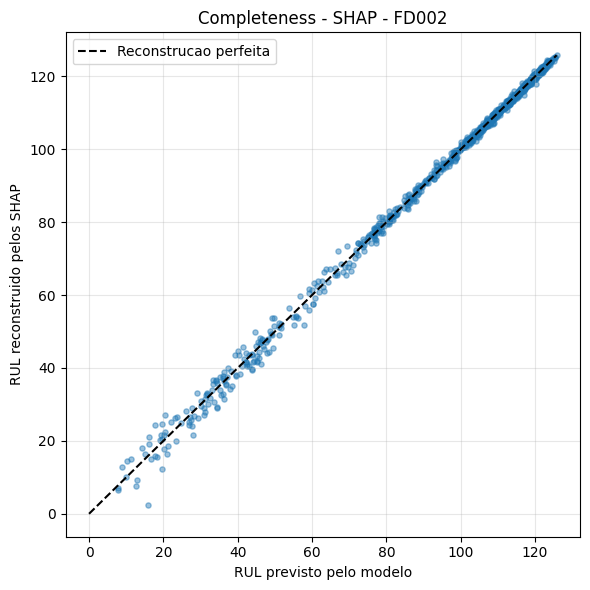

In [8]:
shap_fd002 = ShapExplainer(model_path_002, x_path_002, y_path_002, background_size=100)
resultados_completeness_fd002, resumo_completeness_fd002 = avaliar_completeness_shap(
    shap_fd002, num_instancias=1000
)

display(resumo_completeness_fd002.to_frame('FD002').round(4))
display(resultados_completeness_fd002.head(10).round(4))
plotar_completeness(resultados_completeness_fd002, dataset='FD002')

### Análise - FD002

No FD002, o MAE de completeness foi de 0,839 ciclo e a mediana do erro absoluto foi de 0,489, indicando boa reconstrução na maior parte das janelas. O maior erro observado foi de 13,610 ciclos, o que aumenta o RMSE para 1,387 e mostra a existência de poucos casos em que a aproximação do GradientExplainer é menos precisa.

,FD003
Valor-base,124.0925
MAE de completeness,0.9084
RMSE de completeness,1.6177
Mediana do erro absoluto,0.4106
Maior erro absoluto,11.6373


,Amostra,RUL previsto pelo modelo,RUL reconstruido pelos SHAP,Erro absoluto de completeness
0,0,125.189102,125.0704,0.1187
1,1,125.418297,125.5566,0.1382
2,2,125.259003,125.0854,0.1737
3,3,125.457703,125.5367,0.0790
4,4,124.495598,124.6083,0.1127
5,5,125.711098,125.6020,0.1091
6,6,125.195999,124.9351,0.2610
7,7,125.685204,125.9706,0.2854
8,8,122.679802,122.7670,0.0872
9,9,124.524300,124.6095,0.0852


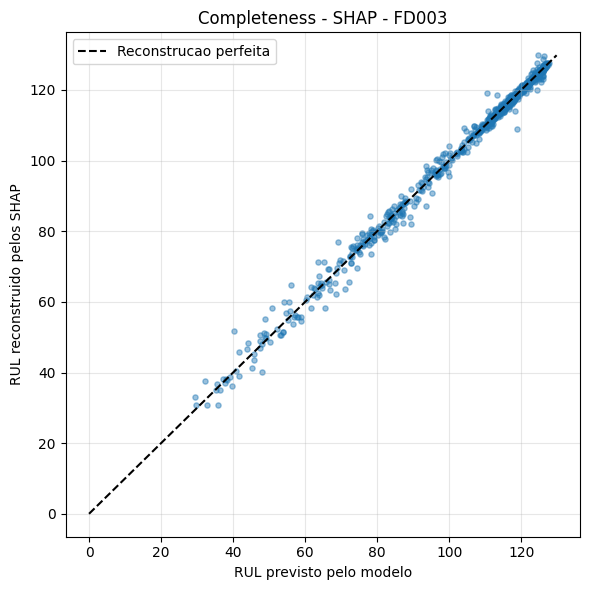

In [9]:
shap_fd003 = ShapExplainer(model_path_003, x_path_003, y_path_003, background_size=100)
resultados_completeness_fd003, resumo_completeness_fd003 = avaliar_completeness_shap(
    shap_fd003, num_instancias=1000
)

display(resumo_completeness_fd003.to_frame('FD003').round(4))
display(resultados_completeness_fd003.head(10).round(4))
plotar_completeness(resultados_completeness_fd003, dataset='FD003')

### Análise - FD003

O FD003 também apresentou boa completeness: MAE de 0,908 ciclo e mediana de 0,411. Apesar de alguns casos mais discrepantes, evidenciados pelo maior erro de 11,637 ciclos e RMSE de 1,618, a baixa mediana indica que a reconstrução é precisa para a maior parte das 1000 janelas analisadas.

,FD004
Valor-base,116.4594
MAE de completeness,0.6689
RMSE de completeness,1.4739
Mediana do erro absoluto,0.1806
Maior erro absoluto,12.1576


,Amostra,RUL previsto pelo modelo,RUL reconstruido pelos SHAP,Erro absoluto de completeness
0,0,116.707001,116.7047,0.0022
1,1,116.483299,116.4907,0.0074
2,2,116.750801,116.7859,0.0351
3,3,116.757500,116.7298,0.0277
4,4,117.375298,117.4467,0.0714
5,5,116.737900,116.7764,0.0385
6,6,116.696602,116.7156,0.0189
7,7,116.652397,116.6420,0.0104
8,8,116.717400,116.7043,0.0131
9,9,116.776802,116.7347,0.0421


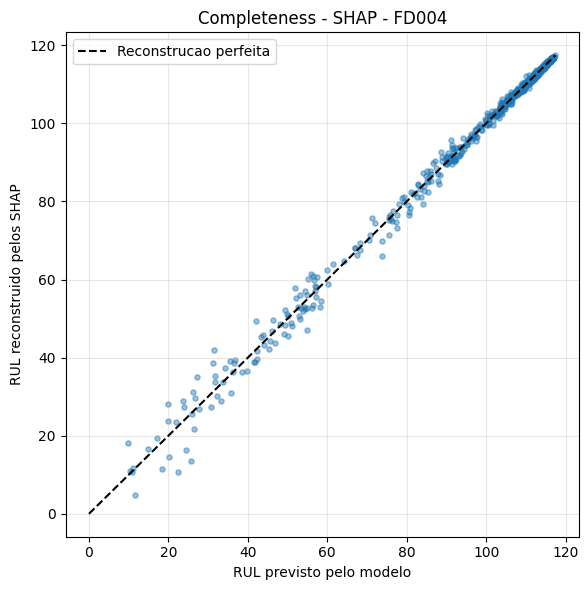

In [10]:
shap_fd004 = ShapExplainer(model_path_004, x_path_004, y_path_004, background_size=100)
resultados_completeness_fd004, resumo_completeness_fd004 = avaliar_completeness_shap(
    shap_fd004, num_instancias=1000
)

display(resumo_completeness_fd004.to_frame('FD004').round(4))
display(resultados_completeness_fd004.head(10).round(4))
plotar_completeness(resultados_completeness_fd004, dataset='FD004')

### Análise - FD004

O FD004 apresentou o menor MAE de completeness, 0,669 ciclo, e a menor mediana de erro absoluto, 0,181 ciclo. Portanto, para a maioria das janelas, a previsão reconstruída pelos valores SHAP ficou muito próxima da saída original da rede. Existem poucos erros maiores, refletidos no RMSE de 1,474, mas o resultado geral continua muito bom.

### Análise geral - Completeness

Os quatro datasets apresentaram boa completeness, pois o MAE entre a previsão da CNN-LSTM e a reconstrução por SHAP ficou abaixo de 1 ciclo de RUL em todos os casos. O FD004 obteve o menor MAE (0,669) e a menor mediana (0,181), enquanto FD002 e FD003 apresentaram alguns poucos erros altos, que elevaram seus valores de RMSE. Como foi usado o GradientExplainer, os valores SHAP são aproximados; por isso, o erro não precisa ser exatamente zero. Ainda assim, os resultados indicam que a soma das atribuições representa quase toda a decisão numérica do modelo.

Estudar:

https://aix360.factsheets.vpc.res.ibm.com/

https://pair-code.github.io/what-if-tool/learn/